In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [4]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                    

In [5]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

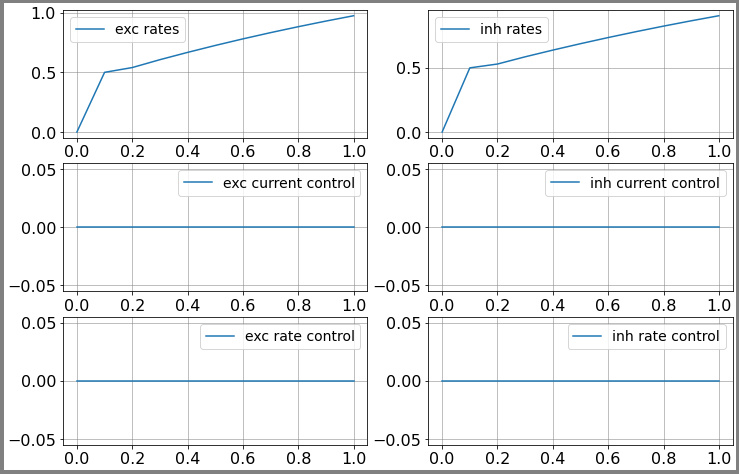

[[0.         0.04       0.0762     0.109676   0.14070688 0.1695773
  0.19653032 0.22177543 0.24549258 0.26783615 0.2889383 ]]


In [156]:
aln = RateModel()

aln.params.dt = 0.1
aln.params['duration'] = 1.
control0 = aln.getZeroControl()
target = aln.getZeroTarget()
#control0 = step_control(maxI_ = 1.)

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.5
aln.params.mui_ext_mean = 0.5
aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5
aln.params.ext_exc_current = 0.

#aln.params.c_gl = 1.
#aln.params.Ke_gl = 1.
#aln.params.tau_se = 1.
#aln.params.Jee_max = 1.
#aln.params.C = 1.
#aln.params.gL = 1.
#aln.params.cee = 1.
#aln.params.Ke = 1.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroFullState()
plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

for i in range(len(state_vars)):
    state[:,i,:] = aln.state[state_vars[i]]

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]
        
high_state_vars[5] = 0.
high_state_vars[0] = 0.


print(aln.state["mufe"])

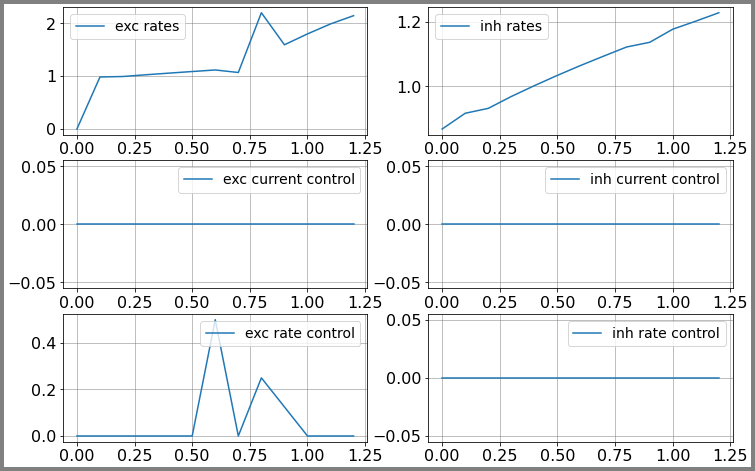

no delay : 
exc rates :  [0.         0.98410095 0.99330117 1.02635961 1.05723738 1.08745478
 1.11690313 1.06918526 2.19956571 1.59357245 1.79923355 1.98805383
 2.14417274]
inh rates :  [0.86690475 0.91598585 0.93126469 0.96827862 1.00198068 1.03414209
 1.06474645 1.09388204 1.12248001 1.13704143 1.17786943 1.20297585
 1.22924466]


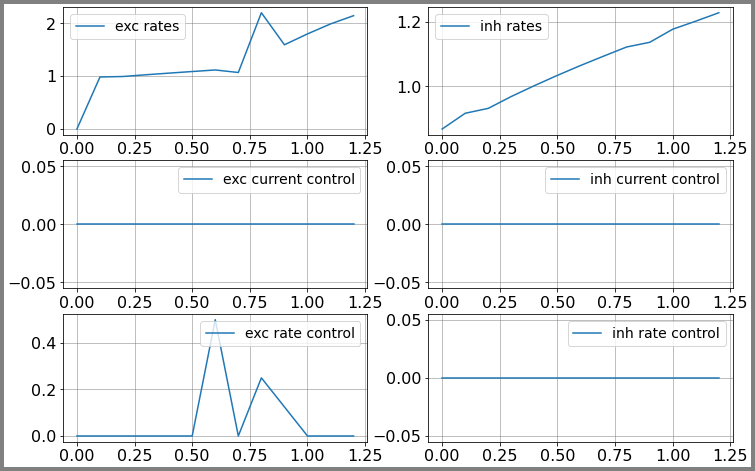

delay : 
exc rates :  [0.         0.98410095 0.99330117 1.02635961 1.05723738 1.08745478
 1.11690313 1.06918526 2.19956571 1.59357245 1.79923355 1.98805383
 2.14417274]
inh rates :  [0.86690475 0.91598585 0.93126469 0.96827862 1.00198068 1.03414209
 1.06474645 1.09388204 1.12248001 1.13704143 1.17786943 1.20297585
 1.22924466]


In [157]:
dur = 0.8
dur_pre = 0.4
dur_post = 0.4

n_dur = int(dur/aln.params.dt + 1)
n_pre = int(dur_pre/aln.params.dt + 1)

aln.params.duration = dur + dur_pre

control_ind = [2]
prec_var = [0]

if control_ind == 0 or control_ind == 1 or control_ind == [0,1]:
    max_cntrl = 2.
    min_cntrl = -2.
else:
    max_cntrl = 0.5
    min_cntrl = 0.


control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    control0[0,j,n_pre + 1] =  max_cntrl + 0.5 * j * min_cntrl
    control0[0,j,n_pre + 2] =  min_cntrl
    control0[0,j,n_pre + 3] = 0.5*max_cntrl - 0.3 * j * min_cntrl
    control0[0,j,n_pre + 4] = (0.5*max_cntrl + min_cntrl)/2

#control0[0,1,:] = 0.    

setinitvars(high_state_vars)

aln.params.de = 0.
plotFunc.plot_traces(aln, control0)
print("no delay : ")
print("exc rates : ", aln.rates_exc[0,:])
print("inh rates : ", aln.rates_inh[0,:])

#aln.params.de = 0.2
plotFunc.plot_traces(aln, control0)
print("delay : ")
print("exc rates : ", aln.rates_exc[0,:])
print("inh rates : ", aln.rates_inh[0,:])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,-n_dur:]
target[0,1,:] = aln.rates_inh[0,-n_dur:]

In [158]:
castparams = [1., 0.0, 0.* 1e-2]
cost.setParams(castparams[0], castparams[1], castparams[2])

setinitvars(high_state_vars)
max_it = 100
start_step = 1.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
#control1[0,0,5] = 0.11
#control2 = bestControlA
#control2 = bestControlA_A2[:,:,:]

# "HS", "FR", "PR", "HZ"
cgv = "HSl"

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 0.0011694607062876605

ERROR:root:Problem in initial value trasfer


set cost params
RUN  0 , total integrated cost =  0.14173424504889492
No valid variant of conjugate gradient descent selected, use none instead.
RUN  1 , total integrated cost =  0.031859665004993994
RUN  2 , total integrated cost =  0.031858025474243316
RUN  3 , total integrated cost =  0.031185231217048928
RUN  4 , total integrated cost =  0.027697952241769387
RUN  5 , total integrated cost =  0.027697952241769373
RUN  6 , total integrated cost =  0.027697952241769363
RUN  7 , total integrated cost =  0.027697952241769363
Control only changes marginally.
Improved over  7  iterations by  80.45782638330331  percent.
Problem in initial value trasfer:  sigmae_f 0.7820940871769263 0.7151539802678838
control ind  2
grad =  [-1.71119943e-01 -1.59732782e-01 -9.63886166e-03  3.03784492e-03
  2.61341129e-03  1.94171242e-03  1.36002667e-05 -1.95995308e-06
  0.00000000e+00]
best control =  [0.         0.         0.         0.         0.26130417 0.5
 0.14283032 0.5        0.39062348 0.43654553 0.

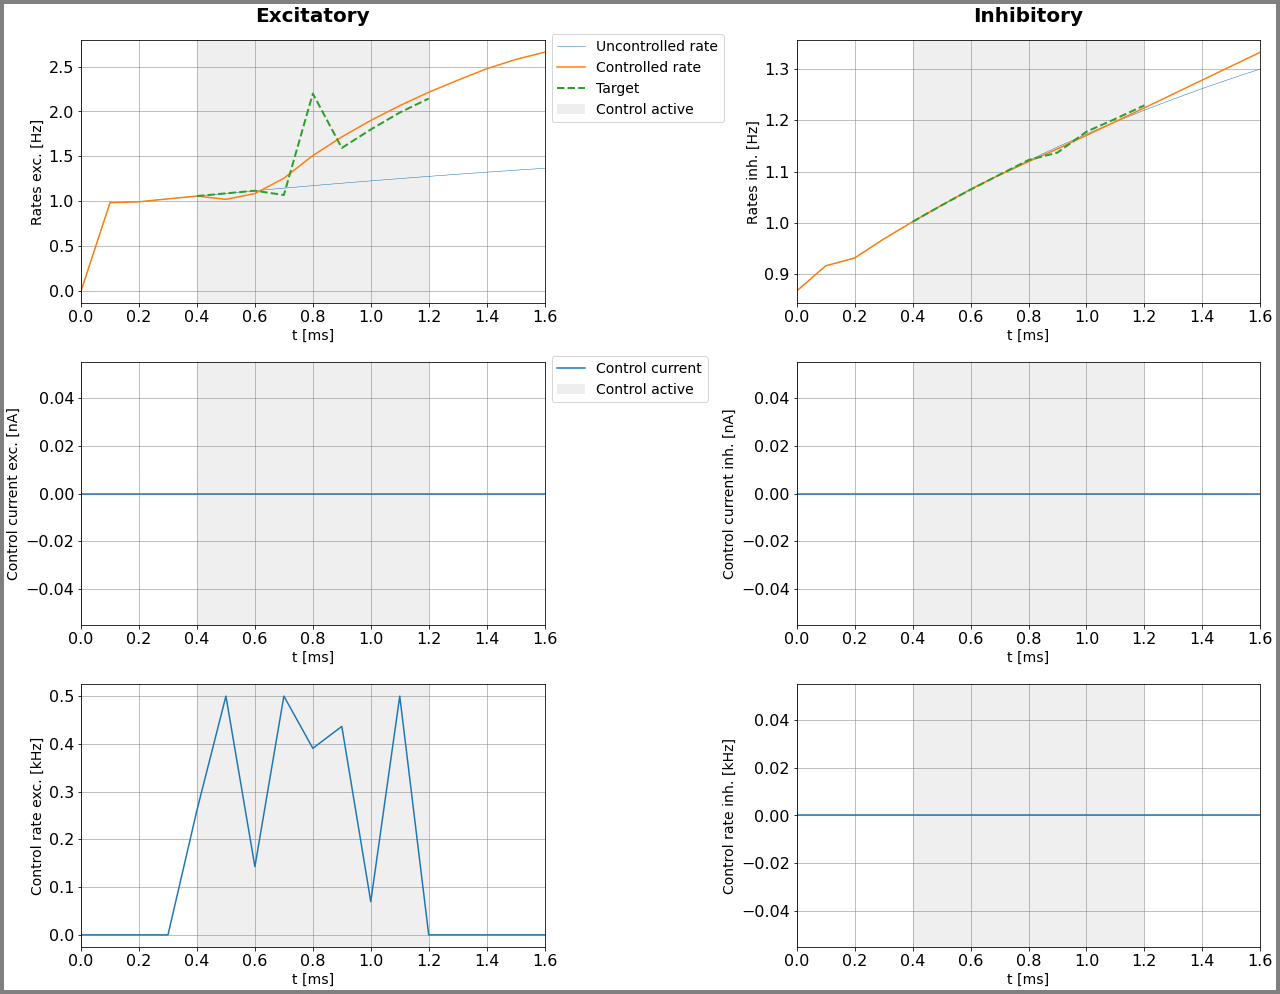

In [159]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [160]:
cost.setParams(castparams[0], castparams[1], castparams[2])
setinitvars(high_state_vars)
max_it = 100
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
#control4 = bestControlA_A2[:,:,:]

#print("start")

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

#0.003933378523157236

set cost params
RUN  0 , total integrated cost:  0.14173424504889492
RUN  1 , total integrated cost:  0.02765553449737071
RUN  2 , total integrated cost:  0.013853514292096011
RUN  3 , total integrated cost:  0.012994362187408242
RUN  4 , total integrated cost:  0.01296706137176492
RUN  5 , total integrated cost:  0.012965473904171134
RUN  6 , total integrated cost:  0.012965365651667138
RUN  7 , total integrated cost:  0.012965365651667097
RUN  8 , total integrated cost:  0.01296536565166706


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  9 , total integrated cost:  0.01296536565166706
Problem in initial value trasfer:  sigmae_f 0.7820940871769263 0.7222568332625748


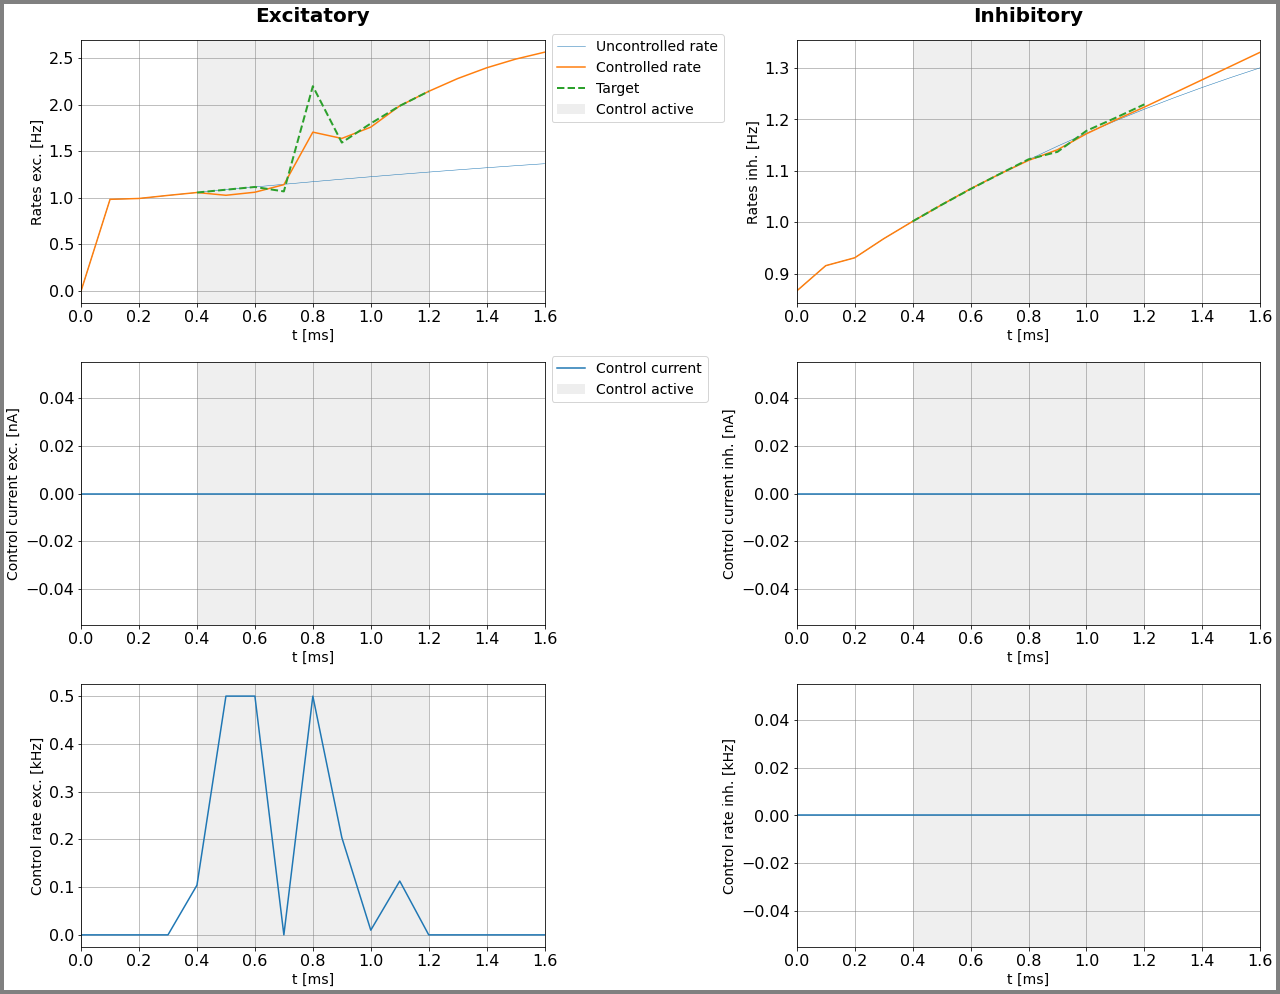

In [161]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

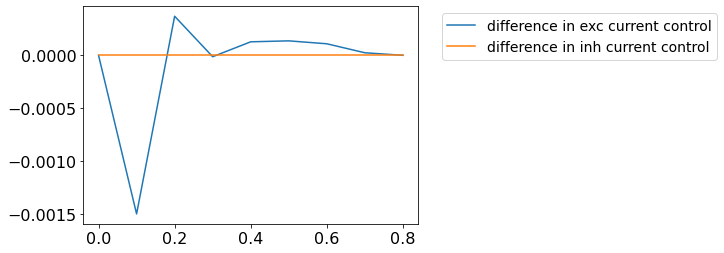

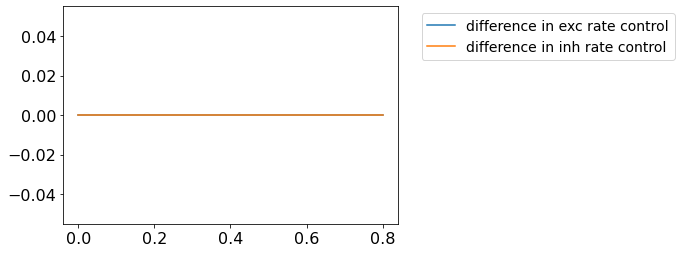

In [114]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

### Testcases for delay
- same precision as control, delay, precision only => check 
- same precision as control, delay, p+e+s => gradient not quite as small (0: ~1e-5, 1: ~1e-3)
- different precision as control, precision only => 0+1, 1+0, 0+2, 1+2 => check
- different precision as control, p+e+s

same: 0, 1
different: 0+1, 0+2, 1+0, 1+2